# Heart Disease Classification — Week 5 Challenge

For this week's challenge I'm predicting whether a patient has heart disease using the classic UCI heart disease dataset. The plan is to start simple with Logistic Regression as a baseline, then move up to Decision Tree, Random Forest, and XGBoost, and finally see if tuning the best models can squeeze out any extra performance.

Along the way I ran into a data leakage issue that completely changed my results, so I've documented that too since it ended up being the most important part of this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings;warnings.filterwarnings("ignore")

## Step 1: Load & Clean the Data

Reading in the dataset and doing some basic housekeeping — renaming the columns to something readable (no one wants to work with `trestbps` when `resting_bp` makes more sense), then checking for nulls and duplicates before doing anything else.

In [4]:
df=pd.read_csv('C:/Users/HP/Desktop/Arcana Internship/Classificaton Challenge/heart.csv')

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
df= df.rename(columns={
    "cp": "chest_pain_type",
    "trestbps": "resting_bp",
    "chol": "cholesterol",
    "fbs": "fasting_blood_sugar_high",
    "restecg": "resting_ecg",
    "thalach": "max_heart_rate",
    "exang": "exercise_induced_angina",
    "oldpeak": "st_depression",
    "slope": "st_slope",
    "ca": "num_major_vessels",
    "thal": "thalassemia"
})

In [7]:
df.head(10)

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar_high,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [8]:
df.shape

(1025, 14)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1025 non-null   int64  
 1   sex                       1025 non-null   int64  
 2   chest_pain_type           1025 non-null   int64  
 3   resting_bp                1025 non-null   int64  
 4   cholesterol               1025 non-null   int64  
 5   fasting_blood_sugar_high  1025 non-null   int64  
 6   resting_ecg               1025 non-null   int64  
 7   max_heart_rate            1025 non-null   int64  
 8   exercise_induced_angina   1025 non-null   int64  
 9   st_depression             1025 non-null   float64
 10  st_slope                  1025 non-null   int64  
 11  num_major_vessels         1025 non-null   int64  
 12  thalassemia               1025 non-null   int64  
 13  target                    1025 non-null   int64  
dtypes: float64(1), int6

In [10]:
df.describe()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar_high,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [11]:
df.isnull().sum()

age                         0
sex                         0
chest_pain_type             0
resting_bp                  0
cholesterol                 0
fasting_blood_sugar_high    0
resting_ecg                 0
max_heart_rate              0
exercise_induced_angina     0
st_depression               0
st_slope                    0
num_major_vessels           0
thalassemia                 0
target                      0
dtype: int64

### Checking for Duplicates

Before going any further, I want to check if there are duplicate rows sitting in here — if the same patient record shows up more than once, it can mess with the model later (more on that below).

In [12]:
df.duplicated().sum()

np.int64(723)

In [13]:
duplicates = df[df.duplicated()]
duplicates.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar_high,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
15,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
43,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
55,55,1,0,140,217,0,1,111,1,5.6,0,0,3,0
61,66,0,2,146,278,0,0,152,0,0.0,1,1,2,1


In [14]:
duplicate_index = duplicates.index[0]
print(df.loc[duplicate_index])

age                          34.0
sex                           0.0
chest_pain_type               1.0
resting_bp                  118.0
cholesterol                 210.0
fasting_blood_sugar_high      0.0
resting_ecg                   1.0
max_heart_rate              192.0
exercise_induced_angina       0.0
st_depression                 0.7
st_slope                      2.0
num_major_vessels             0.0
thalassemia                   2.0
target                        1.0
Name: 15, dtype: float64


In [15]:
df[(df == df.loc[15]).all(axis=1)]

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar_high,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
12,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
15,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
779,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1


In [16]:
df= df.drop_duplicates()

In [17]:
df.shape

(302, 14)

### Wait — I Almost Got Fooled by My Own Data 🚩

Okay so here's what actually happened. The first time I ran this whole notebook (train/test split, all four models, tuning — everything), my results were *too* good. Like, AUC = 1.0 and 98%+ accuracy across the board. At first I was excited, but that's honestly a red flag, not a win — no model predicts heart disease with zero mistakes on real patient data.

I went back and checked `df.duplicated().sum()` and found **723 duplicate rows** out of 1025 — meaning the same patient record was copy-pasted into the dataset multiple times. Since I hadn't dropped these before splitting into train/test, the exact same rows ended up on both sides of the split. So my model wasn't really being tested on unseen data — it had literally already seen those rows during training. That's called **data leakage**, and it's why my scores looked unrealistically perfect.

**Fix:** I dropped the duplicates with `df.drop_duplicates()`, which brought the dataset down to **302 unique rows**. Then I re-ran the entire pipeline from scratch on the clean data. Scores dropped to a much more believable 80–90% range — which is actually the good outcome here, since it means the model is learning real patterns instead of just memorizing repeated rows.

**Lesson learned:** always check for duplicates *before* splitting the data, not after.

In [18]:
df.skew()

age                        -0.203743
sex                        -0.786120
chest_pain_type             0.493022
resting_bp                  0.716541
cholesterol                 1.147332
fasting_blood_sugar_high    1.981201
resting_ecg                 0.169467
max_heart_rate             -0.532671
exercise_induced_angina     0.737281
st_depression               1.266173
st_slope                   -0.503247
num_major_vessels           1.295738
thalassemia                -0.481232
target                     -0.173691
dtype: float64

In [19]:
df.kurt()

age                        -0.527512
sex                        -1.391273
chest_pain_type            -1.183729
resting_bp                  0.922996
cholesterol                 4.542591
fasting_blood_sugar_high    1.937947
resting_ecg                -1.359464
max_heart_rate             -0.062186
exercise_induced_angina    -1.466170
st_depression               1.567876
st_slope                   -0.629935
num_major_vessels           0.781003
thalassemia                 0.295855
target                     -1.983008
dtype: float64

### Checking for Outliers

Running an IQR-based check across the numeric columns to see if anything looks off. A few columns show flagged "outliers," but for medical data that's not automatically a bad thing — some of these are just real, extreme (but valid) patient readings.

In [20]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
sex: 0 outliers
chest_pain_type: 0 outliers
resting_bp: 9 outliers
cholesterol: 5 outliers
fasting_blood_sugar_high: 45 outliers
resting_ecg: 0 outliers
max_heart_rate: 1 outliers
exercise_induced_angina: 0 outliers
st_depression: 5 outliers
st_slope: 0 outliers
num_major_vessels: 24 outliers
thalassemia: 2 outliers
target: 0 outliers


In [21]:
cols = ['resting_bp', 'cholesterol', 'max_heart_rate', 'st_depression']

for c in cols:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[c] < lower) | (df[c] > upper)][c]
    
    print(f"\n{c} — {len(outliers)} outliers")
    print(f"Bounds: ({lower:.1f}, {upper:.1f})")
    print(f"Values: {sorted(outliers.unique().tolist())}")


resting_bp — 9 outliers
Bounds: (90.0, 170.0)
Values: [172, 174, 178, 180, 192, 200]

cholesterol — 5 outliers
Bounds: (115.4, 370.4)
Values: [394, 407, 409, 417, 564]

max_heart_rate — 1 outliers
Bounds: (84.1, 215.1)
Values: [71]

st_depression — 5 outliers
Bounds: (-2.4, 4.0)
Values: [4.2, 4.4, 5.6, 6.2]


### So... Should I Remove Any of These?

Short answer: no. Looking at the actual values:
- **resting_bp** (up to 200): high, but plausible for a patient with severe hypertension.
- **cholesterol** (up to 564): also on the extreme end, but real — some patients genuinely have very high cholesterol.
- **max_heart_rate** (as low as 71): reasonable depending on age and fitness level.
- **st_depression**: a few higher values, but nothing that looks like a data entry error.

None of these look like typos or broken sensor readings — they look like real (if extreme) patient values. Removing them would just be throwing away real medical cases, so I'm keeping the dataset as-is.

## Step 2: Explore the Data (EDA)

Time to actually look at the data — distributions of each feature, and how they relate to each other and to the target (whether someone has heart disease or not).

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'chest_pain_type'}>,
        <Axes: title={'center': 'resting_bp'}>],
       [<Axes: title={'center': 'cholesterol'}>,
        <Axes: title={'center': 'fasting_blood_sugar_high'}>,
        <Axes: title={'center': 'resting_ecg'}>,
        <Axes: title={'center': 'max_heart_rate'}>],
       [<Axes: title={'center': 'exercise_induced_angina'}>,
        <Axes: title={'center': 'st_depression'}>,
        <Axes: title={'center': 'st_slope'}>,
        <Axes: title={'center': 'num_major_vessels'}>],
       [<Axes: title={'center': 'thalassemia'}>,
        <Axes: title={'center': 'target'}>, <Axes: >, <Axes: >]],
      dtype=object)

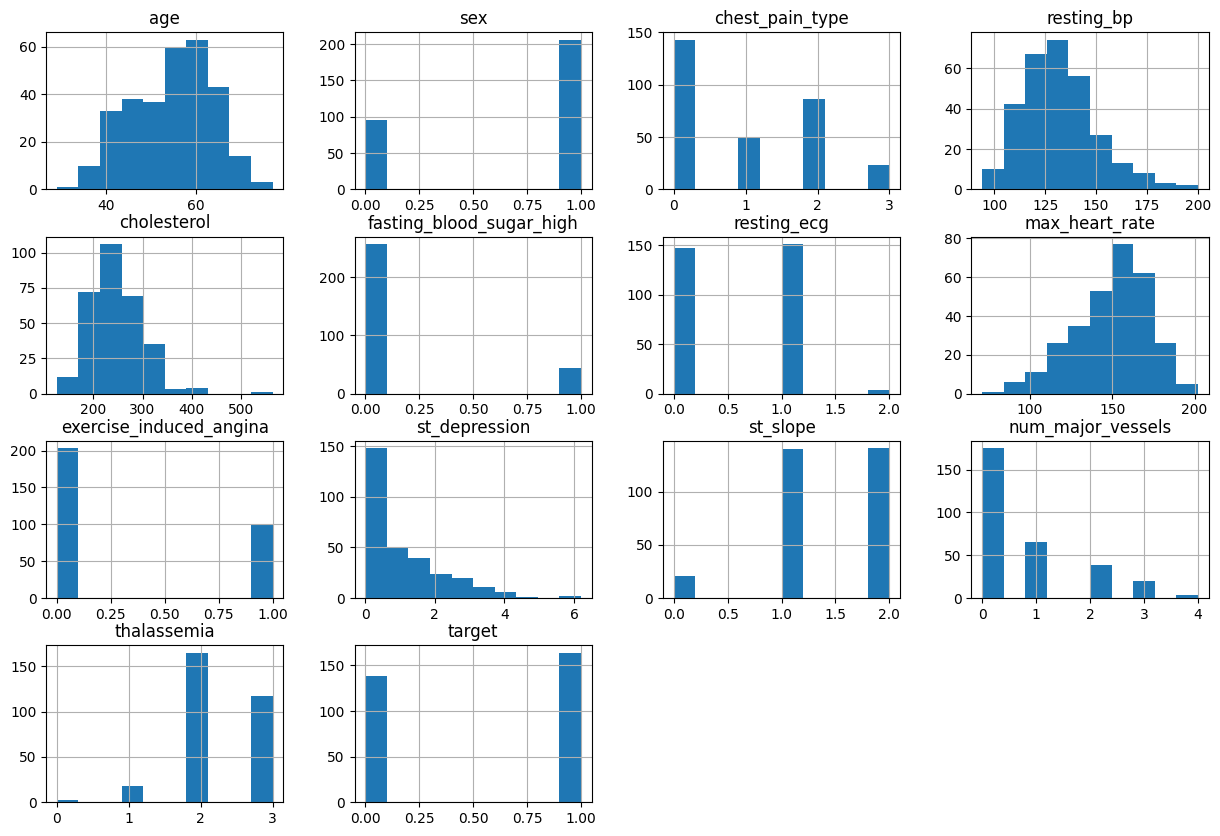

In [22]:
df.hist(figsize=(15,10))

<Axes: >

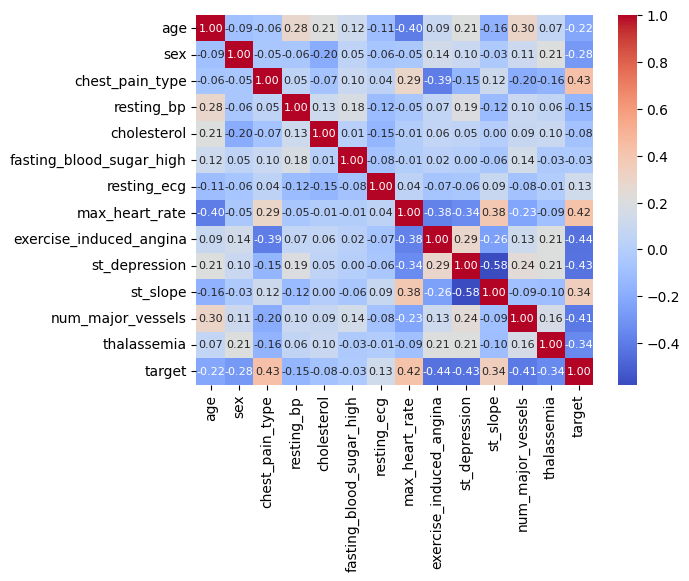

In [23]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm' , fmt=".2f" ,  annot_kws={"size":8})

In [24]:
df['target'].value_counts()
df['target'].value_counts(normalize=True) * 100

target
1    54.304636
0    45.695364
Name: proportion, dtype: float64

### How Balanced Is the Target?

Checking the split between "has heart disease" and "doesn't" — roughly 54% / 46%. That's close enough to balanced that I don't need to worry about class imbalance techniques (like SMOTE) for this one. Good news, one less thing to deal with.

## Step 3: Split the Data & Set Up Evaluation

Splitting into features (`X`) and target (`y`), then into train/test sets. I'm also setting up one reusable `evaluate_model()` function up front so I'm not rewriting the same confusion matrix + metrics code four times over.

In [25]:
X=df.drop('target', axis=1)
y=df['target']

In [26]:
from sklearn.model_selection import train_test_split
np.random.seed(42)

In [27]:
X_train , X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [28]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

In [29]:
def evaluate_model(model, X_test, y_test):

    # Predictions
    y_pred = model.predict(X_test)

    # Prediction probabilities (needed for AUC & ROC)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    print("Confusion Matrix:")
    print(cm)

    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC Score: {auc:.4f}")

    # Classification Report 
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

## Model 1: Logistic Regression (Baseline)

Starting simple. Logistic Regression gives me a baseline to compare everything else against — if my fancier models can't beat this, something's probably wrong.

In [30]:
from sklearn.linear_model import LogisticRegression

In [31]:
logic_reg= LogisticRegression()

In [32]:
logic_reg.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Confusion Matrix:
[[22 10]
 [ 2 27]]


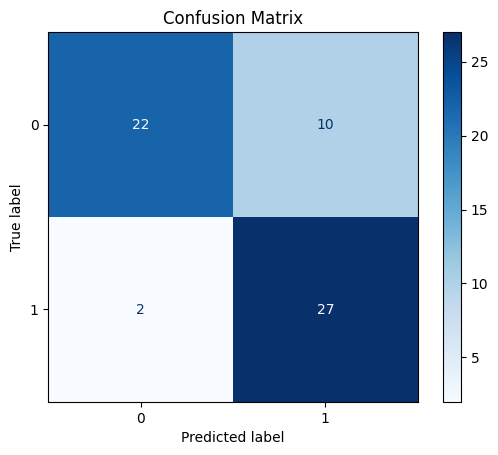

Accuracy : 0.8033
Precision: 0.7297
Recall   : 0.9310
F1 Score : 0.8182
AUC Score: 0.8470

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.69      0.79        32
           1       0.73      0.93      0.82        29

    accuracy                           0.80        61
   macro avg       0.82      0.81      0.80        61
weighted avg       0.83      0.80      0.80        61



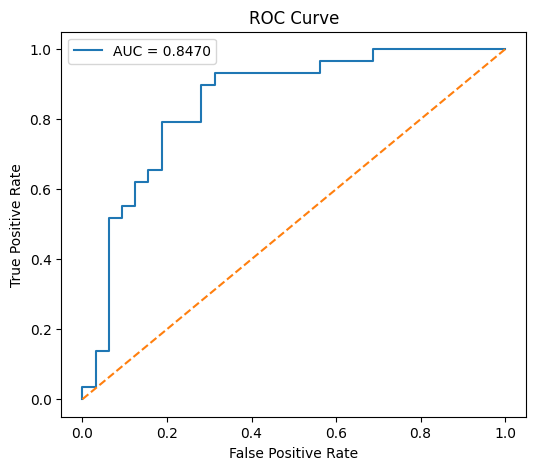

In [33]:
evaluate_model(logic_reg,X_test,y_test)

### Findings — Logistic Regression

Accuracy: 0.803 | Precision: 0.730 | Recall: 0.931 | F1: 0.818 | AUC: 0.847

Confusion matrix: `[[22, 10], [2, 27]]`

Recall is really strong here (0.931) — it only missed 2 actual disease cases out of 29. But precision is lower (0.730), meaning it's flagging quite a few healthy patients as having disease (10 false positives). For a baseline model, this is a solid starting point — high recall is actually the direction I want, since missing a diagnosis is worse than a false alarm. The bar the other models need to clear is this recall/AUC combo.

## Model 2: Decision Tree

A single decision tree — basically a flowchart of yes/no questions that ends in a prediction. Easy to understand, but trees like this tend to overfit (memorize the training data instead of learning general patterns), so I'm not expecting this to be my best model.

In [34]:
from sklearn.tree import DecisionTreeClassifier

In [35]:
decision= DecisionTreeClassifier()

In [36]:
decision.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

Confusion Matrix:
[[25  7]
 [ 9 20]]


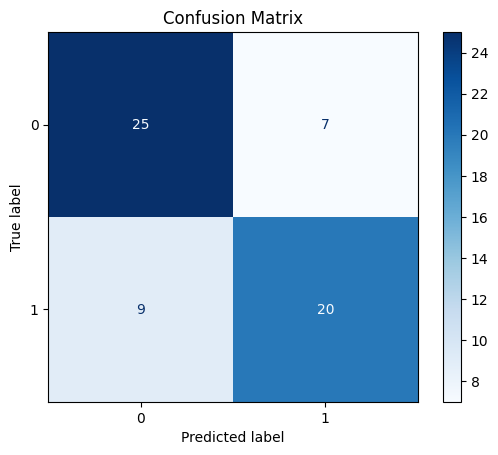

Accuracy : 0.7377
Precision: 0.7407
Recall   : 0.6897
F1 Score : 0.7143
AUC Score: 0.7355

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.78      0.76        32
           1       0.74      0.69      0.71        29

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74      0.74        61



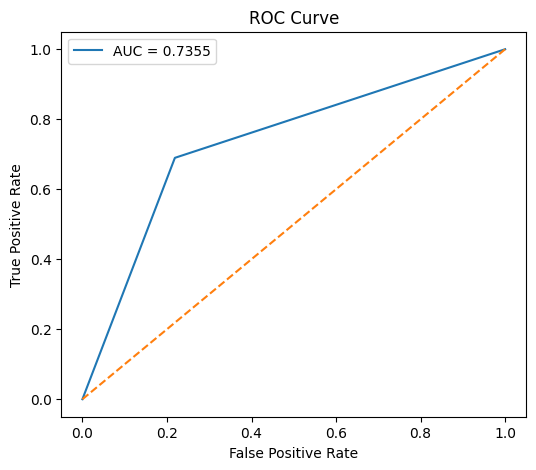

In [37]:
evaluate_model(decision, X_test,y_test)

### Findings — Decision Tree

Accuracy: 0.738 | Precision: 0.741 | Recall: 0.690 | F1: 0.714 | AUC: 0.736

Confusion matrix: `[[25, 7], [9, 20]]`

This is the weakest model so far across every single metric, including the lowest recall (0.690) — it missed 9 out of 29 actual disease cases, way more than Logistic Regression's 2. This lines up with what I expected: a single tree tends to overfit the training data and doesn't generalize as well. Good confirmation that I need the ensemble methods (Random Forest, XGBoost) to actually improve on this.

## Model 3: Random Forest

Instead of one tree, this builds a whole bunch of trees (each trained on a slightly different random slice of the data) and averages their predictions. Should be more stable and less overfit than the single Decision Tree above.

In [38]:
from sklearn.ensemble import RandomForestClassifier

In [39]:
random=RandomForestClassifier()

In [40]:
random.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Confusion Matrix:
[[24  8]
 [ 3 26]]


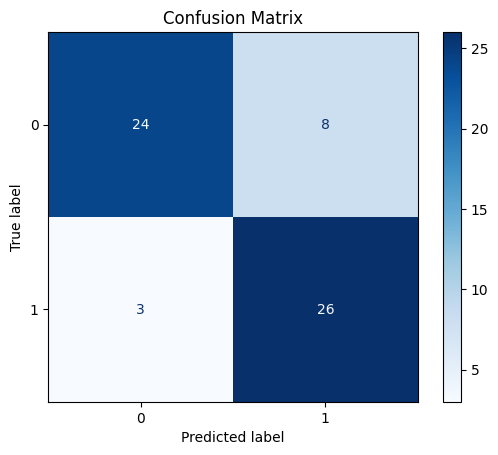

Accuracy : 0.8197
Precision: 0.7647
Recall   : 0.8966
F1 Score : 0.8254
AUC Score: 0.8798

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.75      0.81        32
           1       0.76      0.90      0.83        29

    accuracy                           0.82        61
   macro avg       0.83      0.82      0.82        61
weighted avg       0.83      0.82      0.82        61



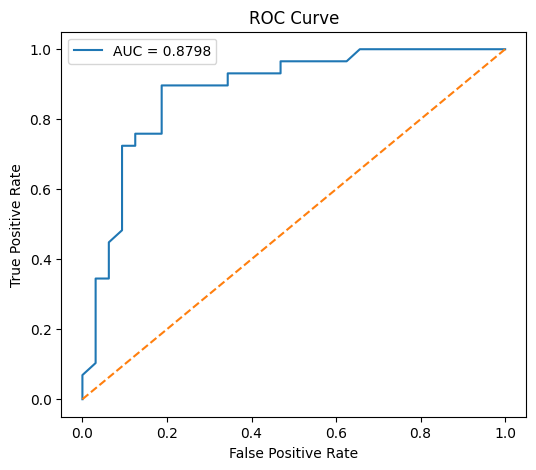

In [41]:
evaluate_model(random,X_test,y_test)

### Findings — Random Forest

Accuracy: 0.820 | Precision: 0.765 | Recall: 0.897 | F1: 0.825 | AUC: 0.880

Confusion matrix: `[[24, 8], [3, 26]]`

Best all-around performer so far — highest accuracy, F1, and AUC of the four baseline models. Recall (0.897) is close to Logistic Regression's but with better precision, so it's catching almost as many disease cases while raising fewer false alarms. This confirms the idea that averaging across multiple trees smooths out the overfitting problem the single Decision Tree had.

## Model 4: XGBoost

This one builds trees one after another, where each new tree tries to fix the mistakes the previous ones made. It's usually the strongest performer on tabular data like this, and it's also the model I'm presenting to the team, so I want to pay extra attention to how it does here.

In [42]:
from xgboost import XGBClassifier

In [43]:
xg= XGBClassifier()

In [44]:
xg.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

Confusion Matrix:
[[24  8]
 [ 4 25]]


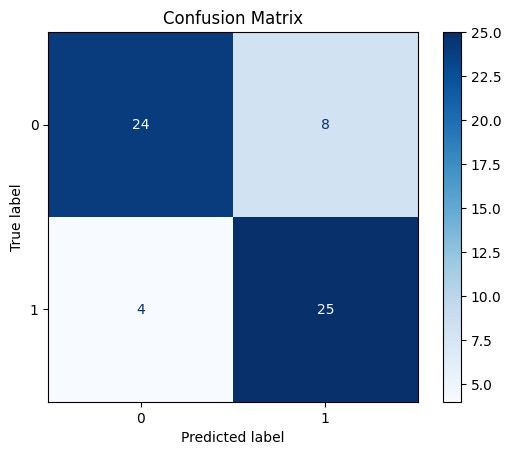

Accuracy : 0.8033
Precision: 0.7576
Recall   : 0.8621
F1 Score : 0.8065
AUC Score: 0.8524

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.75      0.80        32
           1       0.76      0.86      0.81        29

    accuracy                           0.80        61
   macro avg       0.81      0.81      0.80        61
weighted avg       0.81      0.80      0.80        61



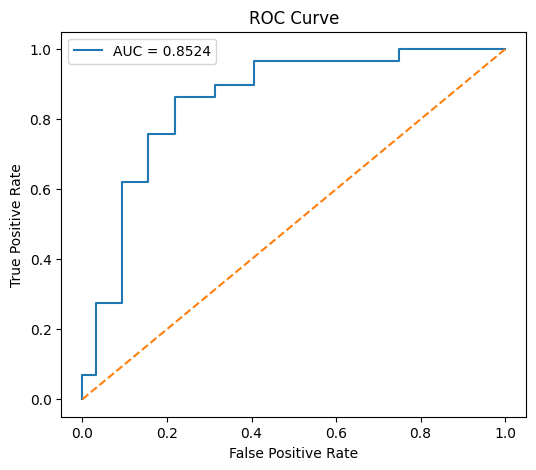

In [45]:
evaluate_model(xg,X_test,y_test)

### Findings — XGBoost

Accuracy: 0.803 | Precision: 0.758 | Recall: 0.862 | F1: 0.807 | AUC: 0.852

Confusion matrix: `[[24, 8], [4, 25]]`

Solid, but slightly behind Random Forest on every metric here (F1 0.807 vs 0.825, AUC 0.852 vs 0.880). A bit surprising since XGBoost usually edges out Random Forest on tabular data — but with only 302 rows, there may not be enough data for XGBoost's sequential boosting to show its usual advantage. Worth keeping in mind for the tuning step below — this is the model I'm presenting on, so I want to see if tuning closes this gap.

## Step 4: Cross-Validation & Hyperparameter Tuning

Before picking a "winner," I want a fairer way to compare models than just one train/test split — a single split can get lucky or unlucky depending on which rows happen to land in the test set. So I'm using **5-fold cross-validation** to get an averaged, more trustworthy score for each model.

After that, I'm using **RandomizedSearchCV** to tune Random Forest and XGBoost — trying out different combinations of settings (like how many trees, how deep they go) to see if I can beat the default settings I used above.

In [46]:
from sklearn.model_selection import GridSearchCV, cross_val_score

# 5-fold cross-validation on the untuned models
for name, model in [("Decision Tree", decision), ("Random Forest", random), ("XGBoost", xg)]:
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    print(f"{name}: F1 = {scores.mean():.3f} (+/- {scores.std():.3f})")

Decision Tree: F1 = 0.744 (+/- 0.026)
Random Forest: F1 = 0.835 (+/- 0.006)
XGBoost: F1 = 0.805 (+/- 0.026)


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'n_estimators': 150, 'min_samples_split': 10, 'max_depth': 5}
Best CV F1: 0.8371914015794902
Confusion Matrix:
[[25  7]
 [ 4 25]]


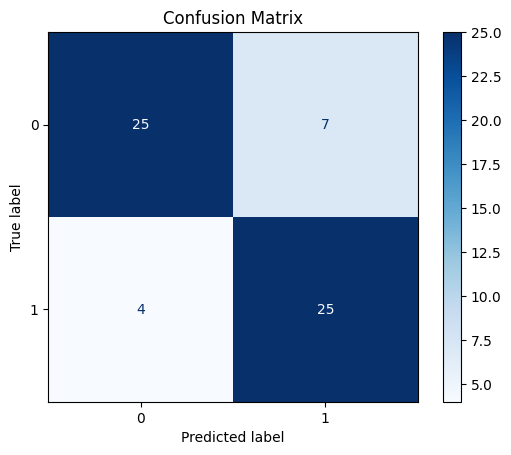

Accuracy : 0.8197
Precision: 0.7812
Recall   : 0.8621
F1 Score : 0.8197
AUC Score: 0.9030

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.78      0.82        32
           1       0.78      0.86      0.82        29

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



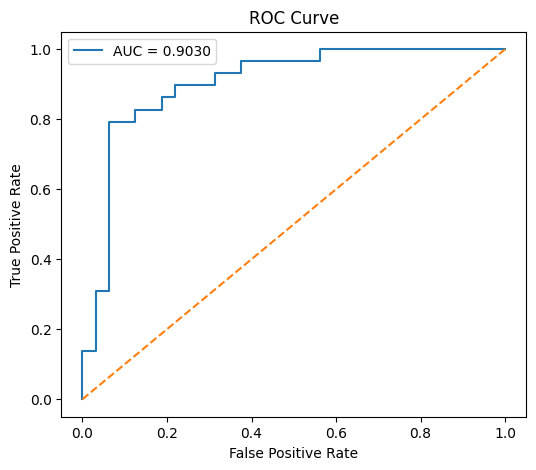

In [47]:
from sklearn.model_selection import RandomizedSearchCV

# Random Forest tuning
param_dist_rf = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

random_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=8,          # only 8 random combos tried
    cv=3,              # 3-fold instead of 5
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_rf.fit(X_train, y_train)

print("Best params:", random_rf.best_params_)
print("Best CV F1:", random_rf.best_score_)

evaluate_model(random_rf.best_estimator_, X_test, y_test)

### Findings — Tuned Random Forest

Best params: `n_estimators=150, min_samples_split=10, max_depth=5`
Accuracy: 0.820 | Precision: 0.781 | Recall: 0.862 | F1: 0.820 | AUC: 0.903

Confusion matrix: `[[25, 7], [4, 25]]`

Tuning gave a real, meaningful AUC boost (0.880 → 0.903) — the best AUC of every model tried. Interestingly, recall actually dropped slightly (0.897 → 0.862, one more missed disease case) while precision improved (0.765 → 0.781). So tuning didn't just blindly improve everything — it shifted the tradeoff toward fewer false positives at the cost of one more false negative. Given that false negatives are the costlier error here, this is worth flagging rather than treating tuning as a pure win.

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2}
Best CV F1: 0.7988424498863992
Confusion Matrix:
[[24  8]
 [ 4 25]]


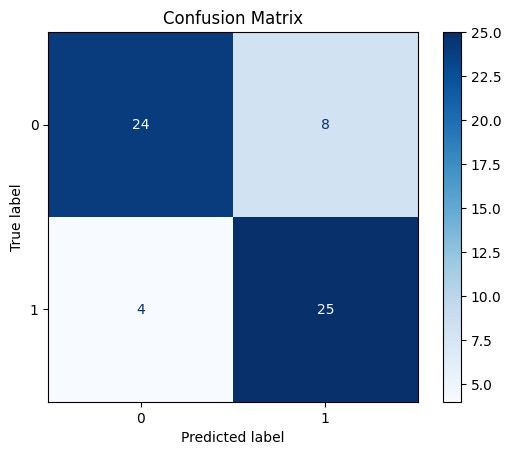

Accuracy : 0.8033
Precision: 0.7576
Recall   : 0.8621
F1 Score : 0.8065
AUC Score: 0.8556

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.75      0.80        32
           1       0.76      0.86      0.81        29

    accuracy                           0.80        61
   macro avg       0.81      0.81      0.80        61
weighted avg       0.81      0.80      0.80        61



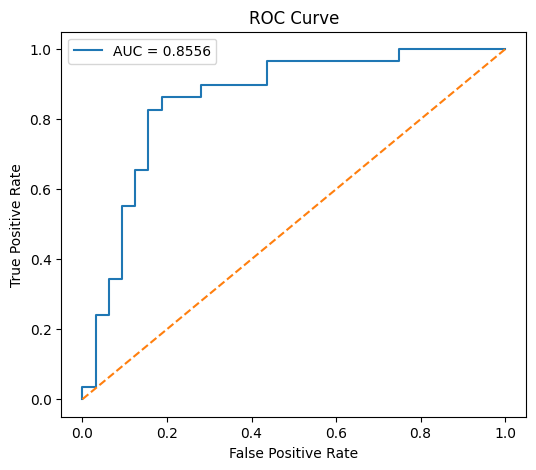

In [48]:
param_dist_xgb = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2]
}

random_xgb = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=param_dist_xgb,
    n_iter=8,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_xgb.fit(X_train, y_train)

print("Best params:", random_xgb.best_params_)
print("Best CV F1:", random_xgb.best_score_)

evaluate_model(random_xgb.best_estimator_, X_test, y_test)

### Findings — Tuned XGBoost

Best params: `n_estimators=200, max_depth=7, learning_rate=0.2`
Accuracy: 0.803 | Precision: 0.758 | Recall: 0.862 | F1: 0.807 | AUC: 0.856

Confusion matrix: `[[24, 8], [4, 25]]`

Almost no change from the untuned XGBoost — AUC only moved from 0.852 to 0.856, and every other metric is identical. This tells me the default XGBoost settings were already close to optimal for this dataset, and my search space (`n_iter=8`) probably didn't explore widely enough to find a meaningfully better combination. Rather than force a "tuning helped a lot!" narrative, I think the honest takeaway is that tuning had diminishing returns here — Random Forest responded to tuning much more than XGBoost did.

## Step 5: Compare Everything Side-by-Side

Time to put every model — baseline and tuned — into one table so I can actually see how they stack up against each other instead of scrolling through six separate outputs.

In [49]:
results = {
    "Logistic Regression": logic_reg,
    "Decision Tree": decision,
    "Random Forest": random,
    "XGBoost": xg,
    "Tuned Random Forest": random_rf.best_estimator_,
    "Tuned XGBoost": random_xgb.best_estimator_
}

comparison = []
for name, model in results.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    comparison.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(comparison).sort_values("F1", ascending=False)
comparison_df

,Model,Accuracy,Precision,Recall,F1,AUC
2,Random Forest,0.819672,0.764706,0.896552,0.825397,0.879849
4,Tuned Random Forest,0.819672,0.781250,0.862069,0.819672,0.903017
0,Logistic Regression,0.803279,0.729730,0.931034,0.818182,0.846983
3,XGBoost,0.803279,0.757576,0.862069,0.806452,0.852371
5,Tuned XGBoost,0.803279,0.757576,0.862069,0.806452,0.855603
1,Decision Tree,0.737705,0.740741,0.689655,0.714286,0.735453


## Final Comparison & Conclusion

| Model | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.803 | 0.730 | 0.931 | 0.818 | 0.847 |
| Decision Tree | 0.738 | 0.741 | 0.690 | 0.714 | 0.736 |
| Random Forest | 0.820 | 0.765 | 0.897 | 0.825 | 0.880 |
| XGBoost | 0.803 | 0.758 | 0.862 | 0.807 | 0.852 |
| **Tuned Random Forest** | 0.820 | 0.781 | 0.862 | 0.820 | **0.903** |
| Tuned XGBoost | 0.803 | 0.758 | 0.862 | 0.807 | 0.856 |

**Winner: Tuned Random Forest.** It has the best AUC by a clear margin (0.903), meaning it separates the two classes more reliably than anything else I tried, even though its accuracy and F1 are basically tied with a few other models. Tuning helped here — it traded a tiny bit of recall for better precision and a nice AUC bump.

**Honest observation:** Tuning XGBoost barely moved the needle — its numbers are almost identical to the untuned version (AUC went from 0.852 to 0.856). That's actually a fine result to report — it just means the default XGBoost settings were already close to optimal for this dataset, and my search space maybe wasn't wide enough to find a bigger improvement. Not every tuning attempt has to produce a dramatic jump.

**Decision Tree was the weakest across the board** — makes sense, since one single tree tends to overfit and doesn't get the "wisdom of the crowd" benefit that Random Forest and XGBoost get from combining many trees.

**Why the confusion matrix matters here:** for the Tuned Random Forest, 4 out of 29 actual disease cases were missed (false negatives) — a recall of 0.862. In a real clinical setting, that's the error that matters most: missing an actual diagnosis is worse than an unnecessary follow-up test. So even though this model "wins" overall, ~14% of disease cases would still slip through, and that's worth calling out as a real limitation, not just a footnote.

**One more limitation worth mentioning:** after removing duplicates, I only had 302 total patients to work with (~60 in the test set). That's a small test set, so any single-split result carries some noise. The 5-fold CV scores (Random Forest: 0.835 ± 0.006, XGBoost: 0.805 ± 0.026) are probably the more trustworthy numbers here — and Random Forest's tiny standard deviation suggests it's not just accurate, it's *consistently* accurate across different splits of the data.

In [50]:
import pickle

# Save the winning model (Tuned Random Forest — best AUC)
with open('heart_disease_model.pkl', 'wb') as f:
    pickle.dump(random_rf.best_estimator_, f)

# Save the feature column order — the app needs to build inputs in this exact order
with open('model_features.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print("Model and feature list saved!")

Model and feature list saved!
